In [12]:
# Untreated monoculture: locate and load day-average CSVs
roots = [
    joinpath(DATA_ROOT, "Untreated MonoCulture", "20k", "Averages"),
    joinpath(DATA_ROOT, "Untreated MonoCulture", "30k", "Averages"),
]

expected_files = [
    "A2780Naive_day_averages.csv",
    "A2780cis_day_averages.csv",
]

files = String[]
for r in roots
    if isdir(r)
        for ef in expected_files
            fpath = joinpath(r, ef)
            if isfile(fpath)
                push!(files, fpath)
            else
                @warn "Missing expected file: $fpath"
            end
        end
    else
        @warn "Directory not found: $r"
    end
end

if isempty(files)
    @warn "No day-average CSVs found for Untreated MonoCulture under DATA_ROOT=$DATA_ROOT"
else
    println("Found $(length(files)) day-average files:")
    for f in files
        println("  - ", f)
    end
end

# Load into `untreated_datasets` as Dicts with :file, :path, :density, :x, :y, :yerr
untreated_datasets = Dict{Symbol,Any}[]
for f in files
    try
        x, y, yerr = load_day_averages(f)
        den = infer_density(f)
        push!(untreated_datasets, Dict(:file=>basename(f), :path=>f, :density=>den, :x=>x, :y=>y, :yerr=>yerr))
    catch e
        @warn "Failed to load $(basename(f)): $e"
    end
end
println("Loaded $(length(untreated_datasets)) untreated monoculture datasets into `untreated_datasets`.")

Found 4 day-average files:
  - c:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture\20k\Averages\A2780Naive_day_averages.csv
  - c:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture\20k\Averages\A2780cis_day_averages.csv
  - c:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture\30k\Averages\A2780Naive_day_averages.csv
  - c:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture\30k\Averages\A2780cis_day_averages.csv
Loaded 4 untreated monoculture datasets into `untreated_datasets`.


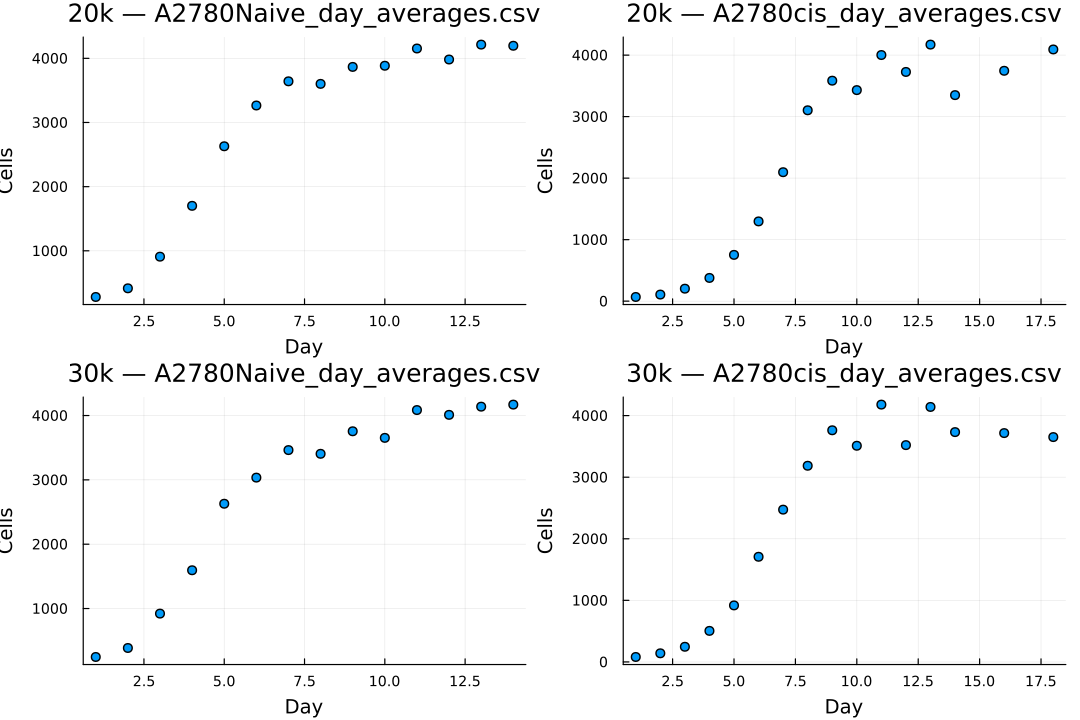

Plotted 4 untreated datasets.


In [15]:
using Plots

# Plot loaded untreated monoculture datasets in a 2x2 (or more) grid
if !(@isdefined untreated_datasets) || isempty(untreated_datasets)
    @warn "No datasets found in `untreated_datasets`. Run the loader cell first."
else
    n = length(untreated_datasets)
    ncols = 2
    nrows = ceil(Int, n / ncols)

    plots_vec = Plots.Plot[]
    for ds in untreated_datasets
        x    = ds[:x]
        y    = ds[:y]
        yerr = get(ds, :yerr, nothing)

        density = get(ds, :density, "unknown_density")
        file    = get(ds, :file, "unknown_file")
        title   = string(density, " — ", file)

        if yerr === nothing
            p = scatter(x, y;
                label="Data",
                xlabel="Day",
                ylabel="Cells",
                title=title,
                markersize=4
            )
        else
            p = scatter(x, y;
                yerror=yerr,
                label="Data",
                xlabel="Day",
                ylabel="Cells",
                title=title,
                markersize=4
            )
        end

        push!(plots_vec, p)
    end

    plt = plot(plots_vec...;
        layout=(nrows, ncols),
        size=(900, 600),
        legend=false
    )
    display(plt)
    println("Plotted $(n) untreated datasets.")
end



===== ODE Logistic Fit Summary =====
Idx   Density             File                                 BIC         r             K             N0          
1     20k                 A2780Naive_day_averages.csv          139.491     0.7715        4070          280.7       
2     20k                 A2780cis_day_averages.csv            178.754     0.7166        3916          67.72       
3     30k                 A2780Naive_day_averages.csv          147.238     0.7815        3966          246.9       
4     30k                 A2780cis_day_averages.csv            175.341     0.7417        3877          80.44       

Plotted and fit 4 untreated datasets with ODE logistic model.


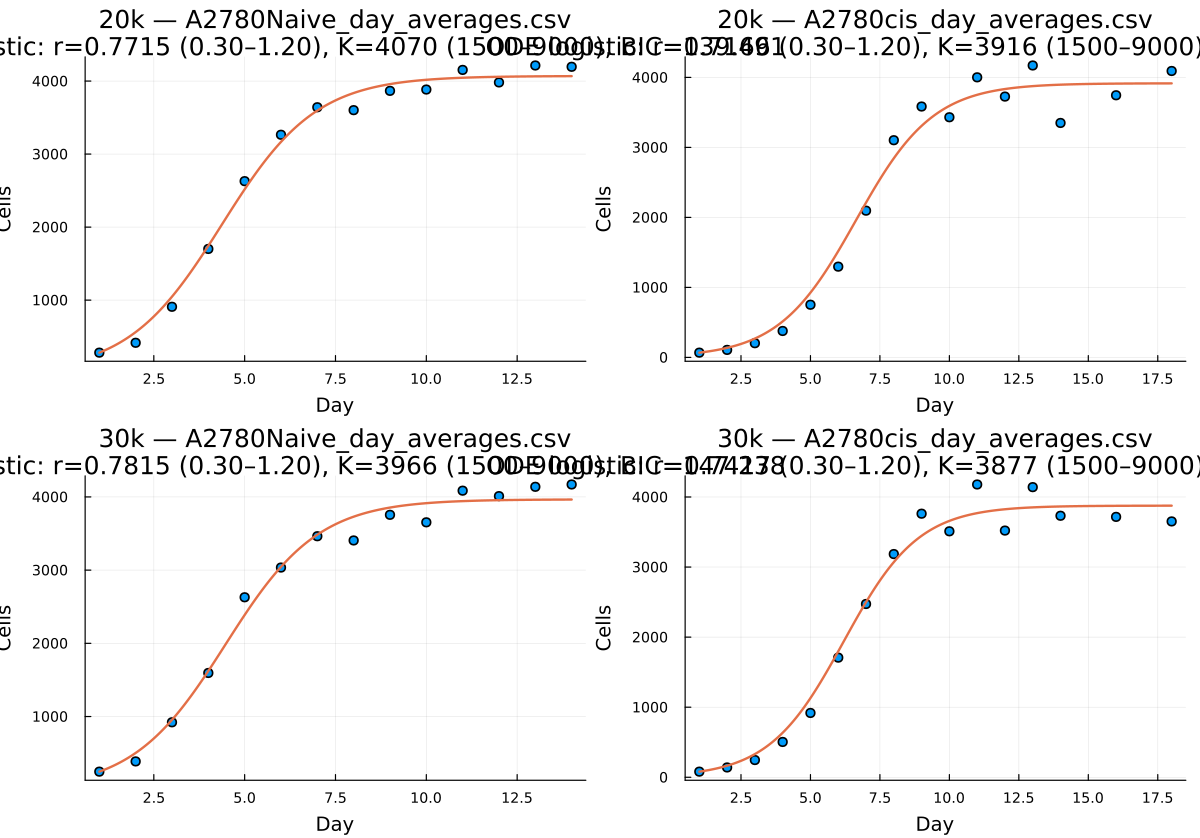

In [19]:
using Plots
using DifferentialEquations
using Optim
using Statistics
using Printf

############################################################
# ODE logistic model + robust fitting (r,K) per dataset
# Constraints / priors you asked for:
#   r in [0.3, 1.2]
#   K around 4000  (we bound it reasonably near there by default)
############################################################

# Logistic ODE: dN/dt = r*N*(1 - N/K)
function logistic_ode!(du, u, p, t)
    r, K = p
    N = u[1]
    du[1] = r * N * (1 - N / K)
end

# Weighted RSS (if yerr provided); otherwise ordinary RSS
function rss(y::AbstractVector, yhat::AbstractVector; yerr=nothing)
    if length(y) != length(yhat)
        error("Length mismatch: length(y)=$(length(y)) vs length(yhat)=$(length(yhat)). Check timepoints / saveat.")
    end
    if yerr === nothing
        r = y .- yhat
        return sum(r .^ 2)
    else
        if length(yerr) != length(y)
            error("Length mismatch: length(yerr)=$(length(yerr)) vs length(y)=$(length(y)).")
        end
        w = 1.0 ./ (yerr .^ 2)
        r = y .- yhat
        return sum(w .* (r .^ 2))
    end
end

# BIC using RSS convention: BIC = n*log(RSS/n) + k*log(n)
function bic_from_rss(RSS::Real, n::Int, k::Int)
    RSS2 = max(RSS, eps(Float64))
    return n * log(RSS2 / n) + k * log(n)
end

# Simulate logistic ODE at times x (vector), given r,K and initial N0.
# IMPORTANT: we sort unique times and then map back to original ordering.
function simulate_logistic_at_times(x_in::AbstractVector{<:Real}, r::Real, K::Real, N0::Real)
    x = Float64.(x_in)
    ord = sortperm(x)
    xs  = x[ord]

    # ensure solver covers the range
    t0, t1 = xs[1], xs[end]
    u0 = [N0]
    p  = (r, K)
    prob = ODEProblem(logistic_ode!, u0, (t0, t1), p)

    # saveat uses sorted times so we get exactly that length
    sol = solve(prob, Tsit5();
        saveat=xs,
        abstol=1e-9, reltol=1e-9,
        maxiters=2_000_000
    )

    y_sorted = Array(sol)[1, :]
    # map back to original order
    yhat = similar(y_sorted)
    yhat[ord] = y_sorted
    return yhat
end

# Fit one dataset with ODE logistic:
# - N0 fixed to first positive y at earliest timepoint
# - r constrained to [r_lo, r_hi]
# - K constrained to [K_lo, K_hi] (defaults centered around 4000)
function fit_logistic_dataset_ode(
    ds;
    dense_grid_points::Int=250,
    maxiters::Int=3000,
    r_lo::Float64=0.3,
    r_hi::Float64=1.2,
    K_lo::Float64=1500.0,
    K_hi::Float64=9000.0
)
    # pull data
    xraw  = Float64.(ds[:x])
    yraw  = Float64.(ds[:y])
    yerr0 = get(ds, :yerr, nothing)
    yerr0 = (yerr0 === nothing) ? nothing : Float64.(yerr0)

    # sort by time (so N0 is consistent)
    ordt = sortperm(xraw)
    x = xraw[ordt]
    y = yraw[ordt]
    yerr = (yerr0 === nothing) ? nothing : yerr0[ordt]

    # keep only positive y (logistic assumes N>0)
    mask = y .> 0
    x = x[mask]; y = y[mask]
    if yerr !== nothing
        yerr = yerr[mask]
    end
    n = length(y)
    n < 3 && error("Need at least 3 positive data points to fit logistic ODE.")

    # N0 fixed to first (earliest) observation
    N0 = y[1]

    # Parameter transform to enforce box constraints:
    # p = lo + (hi-lo)*σ(θ), where σ is logistic sigmoid
    σ(z) = 1.0 / (1.0 + exp(-z))
    function unpack(θ)
        r = r_lo + (r_hi - r_lo) * σ(θ[1])
        K = K_lo + (K_hi - K_lo) * σ(θ[2])
        return r, K
    end

    # initialize near your expectation: r ~ 0.7, K ~ 4000
    r0 = clamp(0.7, r_lo, r_hi)
    K0 = clamp(4000.0, K_lo, K_hi)
    # inverse-sigmoid for initialization in transformed space
    invσ(p) = log(p / (1 - p))
    θ0 = [
        invσ((r0 - r_lo) / (r_hi - r_lo + eps())),
        invσ((K0 - K_lo) / (K_hi - K_lo + eps()))
    ]

    # objective
    function obj(θ)
        r, K = unpack(θ)
        yhat = simulate_logistic_at_times(x, r, K, N0)
        return rss(y, yhat; yerr=yerr)
    end

    # Optim options (positional, compatible with your Optim version)
    opts = Optim.Options(iterations=maxiters, show_trace=false, show_warnings=false)
    res  = optimize(obj, θ0, BFGS(), opts)

    θ̂ = Optim.minimizer(res)
    r̂, K̂ = unpack(θ̂)

    # metrics
    yhat = simulate_logistic_at_times(x, r̂, K̂, N0)
    RSS  = rss(y, yhat; yerr=yerr)
    k    = 2
    BIC  = bic_from_rss(RSS, n, k)

    # dense curve for plotting
    tmin, tmax = minimum(x), maximum(x)
    tgrid = collect(range(tmin, tmax; length=dense_grid_points))
    ygrid = simulate_logistic_at_times(tgrid, r̂, K̂, N0)

    density = get(ds, :density, "unknown_density")
    file    = get(ds, :file, "unknown_file")
    ttl = string(
        density, " — ", file,
        @sprintf("\nODE logistic: r=%.4g (%.2f–%.2f), K=%.4g (%.0f–%.0f), BIC=%.3f",
                 r̂, r_lo, r_hi, K̂, K_lo, K_hi, BIC)
    )

    # plot
    if yerr === nothing
        p = scatter(x, y; label="Data", xlabel="Day", ylabel="Cells", title=ttl, markersize=4)
    else
        p = scatter(x, y; yerror=yerr, label="Data", xlabel="Day", ylabel="Cells", title=ttl, markersize=4)
    end
    plot!(p, tgrid, ygrid; label="ODE logistic fit", linewidth=2)

    return (r=r̂, K=K̂, N0=N0, RSS=RSS, BIC=BIC, plot=p, optim_result=res)
end

############################################################
# Fit all untreated datasets + show plots + print params/BIC
############################################################

if !(@isdefined untreated_datasets) || isempty(untreated_datasets)
    @warn "No datasets found in `untreated_datasets`. Run the loader cell first."
else
    results = Vector{NamedTuple}(undef, length(untreated_datasets))
    plots_vec = Plots.Plot[]

    for (i, ds) in enumerate(untreated_datasets)
        fitres = fit_logistic_dataset_ode(ds;
            r_lo=0.3, r_hi=1.2,
            K_lo=1500.0, K_hi=9000.0,
            maxiters=4000
        )
        results[i] = merge(fitres, (
            density=get(ds, :density, "unknown_density"),
            file=get(ds, :file, "unknown_file"),
        ))
        push!(plots_vec, fitres.plot)
    end

    println("\n===== ODE Logistic Fit Summary =====")
    @printf("%-4s  %-18s  %-35s  %-10s  %-12s  %-12s  %-12s\n",
            "Idx", "Density", "File", "BIC", "r", "K", "N0")
    for (i, r) in enumerate(results)
        @printf("%-4d  %-18s  %-35s  %-10.3f  %-12.4g  %-12.4g  %-12.4g\n",
                i, string(r.density), string(r.file), r.BIC, r.r, r.K, r.N0)
    end

    n = length(plots_vec)
    ncols = 2
    nrows = ceil(Int, n / ncols)
    plt = plot(plots_vec...; layout=(nrows, ncols), size=(1000, 700), legend=false)
    display(plt)

    println("\nPlotted and fit $(n) untreated datasets with ODE logistic model.")
end



===== ODE Logistic Fit Summary (N0 forced at day0) =====
Idx   Density     File                                 BIC         r             K             N0      
1     20k         A2780Naive_day_averages.csv          149.178     0.9311        4016          67      
2     20k         A2780cis_day_averages.csv            194.802     0.6116        3972          67      
3     30k         A2780Naive_day_averages.csv          156.931     0.8182        3950          100     
4     30k         A2780cis_day_averages.csv            195.515     0.5912        3945          100     

Plotted and fit 4 untreated datasets with ODE logistic model (forced day0 N0).


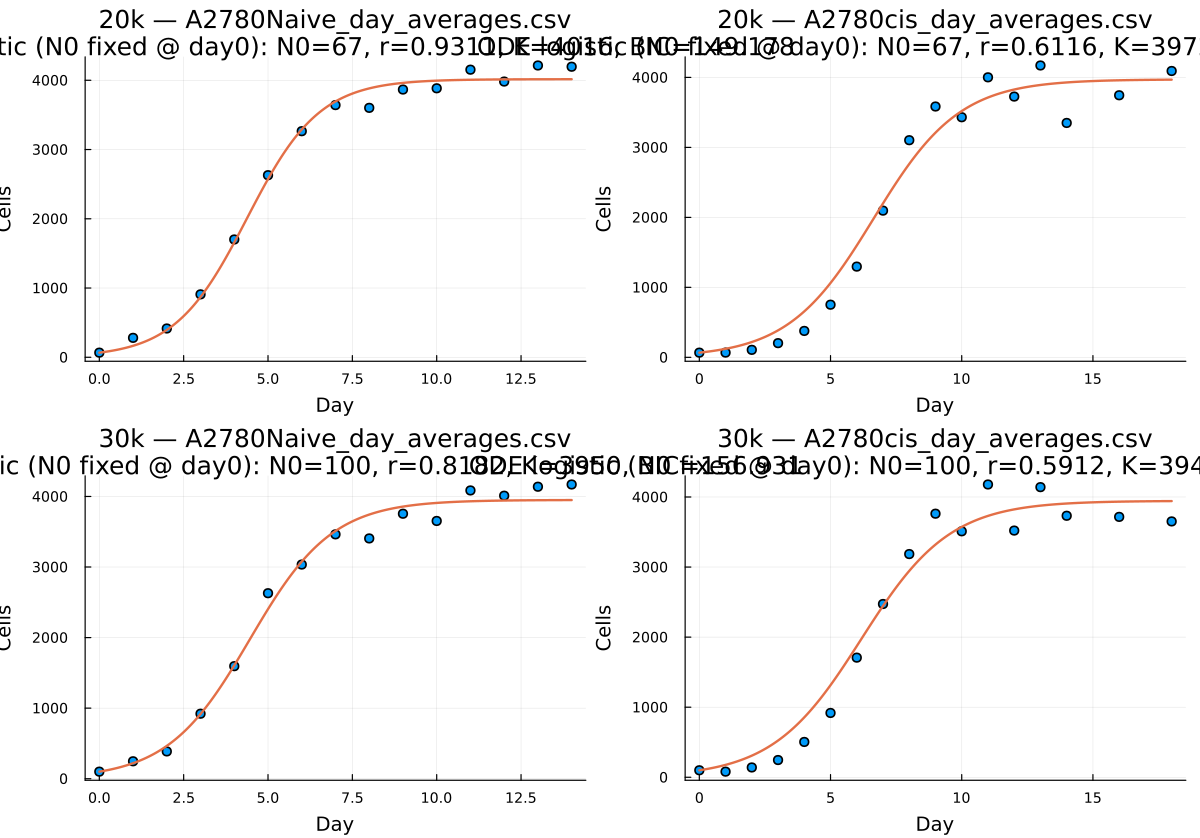

In [20]:
using Plots
using DifferentialEquations
using Optim
using Statistics
using Printf

############################################################
# ODE logistic model + robust fitting (r,K) per dataset
# Requirements:
#   - Force a day 0 point with N0:
#       20k -> N0 = 67
#       30k -> N0 = 100
#   - Fit r in [0.3, 1.2]
#   - K around 4000 (bounded, adjustable)
############################################################

# Logistic ODE: dN/dt = r*N*(1 - N/K)
function logistic_ode!(du, u, p, t)
    r, K = p
    N = u[1]
    du[1] = r * N * (1 - N / K)
end

# Weighted RSS (if yerr provided); otherwise ordinary RSS
function rss(y::AbstractVector, yhat::AbstractVector; yerr=nothing)
    if length(y) != length(yhat)
        error("Length mismatch: length(y)=$(length(y)) vs length(yhat)=$(length(yhat)).")
    end
    if yerr === nothing
        r = y .- yhat
        return sum(r .^ 2)
    else
        if length(yerr) != length(y)
            error("Length mismatch: length(yerr)=$(length(yerr)) vs length(y).")
        end
        w = 1.0 ./ (yerr .^ 2)
        r = y .- yhat
        return sum(w .* (r .^ 2))
    end
end

# BIC using RSS convention: BIC = n*log(RSS/n) + k*log(n)
function bic_from_rss(RSS::Real, n::Int, k::Int)
    RSS2 = max(RSS, eps(Float64))
    return n * log(RSS2 / n) + k * log(n)
end

# Simulate logistic ODE at times x (vector), given r,K and initial N0.
# Sort times -> solve -> map back, guarantees length match.
function simulate_logistic_at_times(x_in::AbstractVector{<:Real}, r::Real, K::Real, N0::Real)
    x = Float64.(x_in)
    ord = sortperm(x)
    xs  = x[ord]
    t0, t1 = xs[1], xs[end]

    prob = ODEProblem(logistic_ode!, [N0], (t0, t1), (r, K))
    sol = solve(prob, Tsit5();
        saveat=xs,
        abstol=1e-9, reltol=1e-9,
        maxiters=2_000_000
    )

    y_sorted = Array(sol)[1, :]
    yhat = similar(y_sorted)
    yhat[ord] = y_sorted
    return yhat
end

# Infer density (20k/30k) and assign forced N0
function forced_N0_from_ds(ds)
    dens = get(ds, :density, nothing)

    if dens === nothing
        # fallback: try to detect from file name
        f = lowercase(string(get(ds, :file, "")))
        if occursin("20k", f)
            return 67.0, "20k"
        elseif occursin("30k", f)
            return 100.0, "30k"
        else
            error("Could not infer density (20k/30k) from ds[:density] or ds[:file]. Add ds[:density] = \"20k\" or \"30k\".")
        end
    end

    dstr = lowercase(string(dens))
    if occursin("20", dstr)
        return 67.0, string(dens)
    elseif occursin("30", dstr)
        return 100.0, string(dens)
    else
        error("Unrecognized density=$(dens). Expected something containing 20k or 30k.")
    end
end

# Ensure day 0 is present (and prepend if missing)
# Optionally assign yerr for day 0; default = nothing (unweighted) or large (if weighted).
function ensure_day0!(x::Vector{Float64}, y::Vector{Float64}, yerr::Union{Nothing,Vector{Float64}}, N0::Float64;
                     day0_yerr::Union{Nothing,Float64}=nothing)
    has0 = any(t -> isapprox(t, 0.0; atol=1e-12), x)
    if !has0
        x = vcat(0.0, x)
        y = vcat(N0, y)
        if yerr !== nothing
            # If weights exist, give day0 a configurable error; if not provided, set to max existing err
            e0 = (day0_yerr === nothing) ? maximum(yerr) : day0_yerr
            yerr = vcat(e0, yerr)
        end
    else
        # overwrite y at day 0 to forced N0 (and optionally yerr)
        idx0 = findfirst(t -> isapprox(t, 0.0; atol=1e-12), x)
        y[idx0] = N0
        if yerr !== nothing && day0_yerr !== nothing
            yerr[idx0] = day0_yerr
        end
    end
    return x, y, yerr
end

# Fit one dataset with ODE logistic (r,K), with forced day0 N0 based on density.
function fit_logistic_dataset_ode(
    ds;
    dense_grid_points::Int=250,
    maxiters::Int=4000,
    r_lo::Float64=0.3,
    r_hi::Float64=1.2,
    K_lo::Float64=1500.0,
    K_hi::Float64=9000.0,
    day0_yerr::Union{Nothing,Float64}=nothing
)
    # load raw
    xraw  = Float64.(ds[:x])
    yraw  = Float64.(ds[:y])
    yerr0 = get(ds, :yerr, nothing)
    yerr0 = (yerr0 === nothing) ? nothing : Float64.(yerr0)

    # sort by time
    ordt = sortperm(xraw)
    x = xraw[ordt]
    y = yraw[ordt]
    yerr = (yerr0 === nothing) ? nothing : yerr0[ordt]

    # force N0 and ensure day0 point exists
    N0, dens_str = forced_N0_from_ds(ds)
    x, y, yerr = ensure_day0!(x, y, yerr, N0; day0_yerr=day0_yerr)

    # keep only positive y
    mask = y .> 0
    x = x[mask]; y = y[mask]
    if yerr !== nothing
        yerr = yerr[mask]
    end

    n = length(y)
    n < 3 && error("Need at least 3 positive data points to fit logistic ODE.")

    # parameter transform enforces box constraints
    σ(z) = 1.0 / (1.0 + exp(-z))
    function unpack(θ)
        r = r_lo + (r_hi - r_lo) * σ(θ[1])
        K = K_lo + (K_hi - K_lo) * σ(θ[2])
        return r, K
    end

    # init near expected: r ~ 0.7, K ~ 4000
    r0 = clamp(0.7, r_lo, r_hi)
    K0 = clamp(4000.0, K_lo, K_hi)
    invσ(p) = log(p / (1 - p))
    θ0 = [
        invσ((r0 - r_lo) / (r_hi - r_lo + eps())),
        invσ((K0 - K_lo) / (K_hi - K_lo + eps()))
    ]

    function obj(θ)
        r, K = unpack(θ)
        yhat = simulate_logistic_at_times(x, r, K, N0)
        return rss(y, yhat; yerr=yerr)
    end

    opts = Optim.Options(iterations=maxiters, show_trace=false, show_warnings=false)
    res  = optimize(obj, θ0, BFGS(), opts)

    θ̂ = Optim.minimizer(res)
    r̂, K̂ = unpack(θ̂)

    yhat = simulate_logistic_at_times(x, r̂, K̂, N0)
    RSS  = rss(y, yhat; yerr=yerr)
    k    = 2
    BIC  = bic_from_rss(RSS, n, k)

    # plotting grid includes day 0
    tmin, tmax = minimum(x), maximum(x)
    tgrid = collect(range(min(0.0, tmin), tmax; length=dense_grid_points))
    ygrid = simulate_logistic_at_times(tgrid, r̂, K̂, N0)

    density = get(ds, :density, dens_str)
    file    = get(ds, :file, "unknown_file")
    ttl = string(
        density, " — ", file,
        @sprintf("\nODE logistic (N0 fixed @ day0): N0=%.0f, r=%.4g, K=%.4g, BIC=%.3f",
                 N0, r̂, K̂, BIC)
    )

    if yerr === nothing
        p = scatter(x, y; label="Data (+day0)", xlabel="Day", ylabel="Cells", title=ttl, markersize=4)
    else
        p = scatter(x, y; yerror=yerr, label="Data (+day0)", xlabel="Day", ylabel="Cells", title=ttl, markersize=4)
    end
    plot!(p, tgrid, ygrid; label="ODE logistic fit", linewidth=2)

    return (r=r̂, K=K̂, N0=N0, RSS=RSS, BIC=BIC, plot=p, optim_result=res,
            density=density, file=file)
end

############################################################
# Fit all untreated datasets + show plots + print params/BIC
############################################################

if !(@isdefined untreated_datasets) || isempty(untreated_datasets)
    @warn "No datasets found in `untreated_datasets`. Run the loader cell first."
else
    results = Vector{NamedTuple}(undef, length(untreated_datasets))
    plots_vec = Plots.Plot[]

    for (i, ds) in enumerate(untreated_datasets)
        fitres = fit_logistic_dataset_ode(ds;
            r_lo=0.3, r_hi=1.2,
            K_lo=1500.0, K_hi=9000.0,
            maxiters=5000,
            day0_yerr=nothing  # set e.g. 5.0 if you want day0 to be strongly weighted when using yerr
        )
        results[i] = fitres
        push!(plots_vec, fitres.plot)
    end

    println("\n===== ODE Logistic Fit Summary (N0 forced at day0) =====")
    @printf("%-4s  %-10s  %-35s  %-10s  %-12s  %-12s  %-8s\n",
            "Idx", "Density", "File", "BIC", "r", "K", "N0")
    for (i, r) in enumerate(results)
        @printf("%-4d  %-10s  %-35s  %-10.3f  %-12.4g  %-12.4g  %-8.0f\n",
                i, string(r.density), string(r.file), r.BIC, r.r, r.K, r.N0)
    end

    n = length(plots_vec)
    ncols = 2
    nrows = ceil(Int, n / ncols)
    plt = plot(plots_vec...; layout=(nrows, ncols), size=(1000, 700), legend=false)
    display(plt)

    println("\nPlotted and fit $(n) untreated datasets with ODE logistic model (forced day0 N0).")
end


In [28]:
using CSV, DataFrames

############################################################
# FIXED: Treated MonoCulture loader (NO Glob)
# - Loads ONLY Averages/*_day_averages.csv by default
# - Returns (treated_by_density_dose, treated_datasets)
# - Adds forced day0 with N0: 20k->67, 30k->100
#
# IMPORTANT: You MUST call it and assign the outputs:
#   treated_by_density_dose, treated_datasets =
#       load_treated_monoculture_datasets(ROOT=ROOT)
############################################################

# --- column detection with fallbacks ---
function _find_col(df::DataFrame, candidates::Vector{String})
    nms = String.(names(df))
    for c in candidates
        idx = findfirst(==(c), nms)
        idx === nothing || return names(df)[idx]
    end
    return nothing
end

# --- infer cell line from filename ---
function infer_cell_line_from_filename(fname::AbstractString)::Symbol
    s = lowercase(fname)
    if occursin("a2780cis", s) || occursin("cis", s)
        return :A2780cis
    elseif occursin("a2780naive", s) || occursin("naive", s)
        return :A2780Naive
    else
        return Symbol(replace(splitext(basename(fname))[1], r"\s+" => "_"))
    end
end

# --- list files in folder (no Glob) ---
function list_files(dir::AbstractString; contains_substr::Union{Nothing,String}=nothing, endswith_substr::Union{Nothing,String}=nothing)
    isdir(dir) || return String[]
    out = String[]
    for f in readdir(dir; join=true)
        isfile(f) || continue
        bn = lowercase(basename(f))
        if contains_substr !== nothing && !occursin(lowercase(contains_substr), bn)
            continue
        end
        if endswith_substr !== nothing && !endswith(bn, lowercase(endswith_substr))
            continue
        end
        push!(out, f)
    end
    sort!(out)
    return out
end

# --- ensure day 0 exists and enforce N0 at day 0 ---
function ensure_day0(x::Vector{Float64}, y::Vector{Float64}, yerr::Union{Nothing,Vector{Float64}}, N0::Float64)
    has0 = any(t -> isapprox(t, 0.0; atol=1e-12), x)
    if !has0
        x = vcat(0.0, x)
        y = vcat(N0, y)
        if yerr !== nothing
            yerr = vcat(maximum(yerr), yerr)  # loose day0 error so it doesn't dominate
        end
    else
        idx0 = findfirst(t -> isapprox(t, 0.0; atol=1e-12), x)
        y[idx0] = N0
    end
    return x, y, yerr
end

# --- load one averages CSV ---
function load_day_averages_csv(path::AbstractString; force_day0::Bool=true, N0::Union{Nothing,Real}=nothing)
    df = CSV.read(path, DataFrame)

    day_col  = _find_col(df, ["Day", "day", "Time", "time", "t"])
    mean_col = _find_col(df, ["Mean Cells", "Mean", "mean", "Cells", "Cell Count", "Mean_Cell_Count"])
    sem_col  = _find_col(df, ["SEM Cells", "SEM", "sem", "StdErr", "SE", "stderr", "SEM_Cell_Count"])
    std_col  = _find_col(df, ["Std Cells", "STD", "std", "Stdev", "SD", "sd"])

    @assert day_col !== nothing && mean_col !== nothing "Required columns not found in $(basename(path)). Columns: $(names(df))"

    x = Float64.(df[!, day_col])
    y = Float64.(df[!, mean_col])

    yerr = nothing
    if sem_col !== nothing
        yerr = Float64.(df[!, sem_col])
    elseif std_col !== nothing
        yerr = Float64.(df[!, std_col])
    end

    ord = sortperm(x)
    x = x[ord]; y = y[ord]
    if yerr !== nothing
        yerr = yerr[ord]
    end

    if force_day0 && N0 !== nothing
        x, y, yerr = ensure_day0(x, y, yerr, Float64(N0))
    end

    return x, y, yerr
end

# --- main loader ---
function load_treated_monoculture_datasets(;
    ROOT::AbstractString,                              # REQUIRE explicit root (prevents silent wrong pwd())
    densities::Vector{String}=["20k","30k"],
    doses::Vector{String}=["IC25","IC50","IC75"],
    dose_uM_by_density::Dict{String,Dict{String,Float64}}=Dict(
        "20k" => Dict("IC25"=>1.47, "IC50"=>1.00, "IC75"=>0.62),
        "30k" => Dict("IC25"=>1.47, "IC50"=>1.00, "IC75"=>0.62),
    ),
    N0_by_density::Dict{String,Float64}=Dict("20k"=>67.0, "30k"=>100.0),
    force_day0::Bool=true,
    file_contains::String="_day_averages",             # ONLY day averages
)
    base = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture")

    treated_by_density_dose = Dict{String, Dict{String, Vector{Dict{Symbol,Any}}}}()
    treated_datasets = Dict{Symbol,Any}[]   # <-- IMPORTANT: return this as 2nd output

    for dens in densities
        dens_dict = Dict{String, Vector{Dict{Symbol,Any}}}()
        N0 = get(N0_by_density, dens, nothing)
        N0 === nothing && error("No N0 specified for density=$dens.")

        for dose in doses
            avg_dir = joinpath(base, dens, dose, "Averages")
            if !isdir(avg_dir)
                @warn "Missing directory: $avg_dir (skipping)"
                dens_dict[dose] = Dict{Symbol,Any}[]
                continue
            end

            files = list_files(avg_dir; contains_substr=file_contains, endswith_substr=".csv")
            dsvec = Dict{Symbol,Any}[]

            for f in files
                fname = basename(f)
                cell_line = infer_cell_line_from_filename(fname)
                x, y, yerr = load_day_averages_csv(f; force_day0=force_day0, N0=N0)

                dose_uM = get(get(dose_uM_by_density, dens, Dict{String,Float64}()), dose, NaN)

                ds = Dict{Symbol,Any}(
                    :x => x,
                    :y => y,
                    :yerr => yerr,
                    :density => dens,
                    :dose_label => dose,
                    :dose_uM => dose_uM,
                    :cell_line => cell_line,
                    :file => fname,
                    :path => f,
                )

                push!(dsvec, ds)
                push!(treated_datasets, ds)
            end

            dens_dict[dose] = dsvec
            println("Loaded $(length(dsvec)) day_averages files for density=$dens, dose=$dose from: $avg_dir")
        end

        treated_by_density_dose[dens] = dens_dict
    end

    # sanity print (should be 12 if 2 densities × 3 doses × 2 cell lines)
    println("TOTAL treated day_averages datasets loaded: $(length(treated_datasets))")

    return treated_by_density_dose, treated_datasets
end

############################################################
# REQUIRED call pattern (do this in its own cell)
############################################################
ROOT = raw"C:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics"
treated_by_density_dose, treated_datasets = load_treated_monoculture_datasets(ROOT=ROOT)


Loaded 2 day_averages files for density=20k, dose=IC25 from: C:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC25\Averages
Loaded 2 day_averages files for density=20k, dose=IC50 from: C:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
Loaded 2 day_averages files for density=20k, dose=IC75 from: C:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC75\Averages
Loaded 2 day_averages files for density=30k, dose=IC25 from: C:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\30k\IC25\Averages
Loaded 2 day_averages files for density=30k, dose=IC50 from: C:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\30k\IC50\Averages
Loaded 2 day_averages files for density=30k, dose=IC75 from: C:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Treate

(Dict{String, Dict{String, Vector{Dict{Symbol, Any}}}}("30k" => Dict("IC50" => [Dict(:yerr => [177.090681, 36.184916, 81.361173, 102.067266, 138.450054, 104.60357, 92.833699, 112.84991, 97.850677, 50.073299, 56.617426, 101.798715, 14.431138, 91.121145, 177.090681], :density => "30k", :file => "A2780Naive_day_averages.csv", :y => [100.0, 277.199035, 512.547261, 810.468596, 1072.597222, 1220.337539, 1524.237886, 1784.317361, 1754.768094, 1630.943518, 1765.695949, 1797.057716, 1664.883989, 1869.518326, 2521.753626], :dose_label => "IC50", :dose_uM => 1.0, :path => "C:\\Users\\elbak\\Desktop\\ForgeLabs\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\30k\\IC50\\Averages\\A2780Naive_day_averages.csv", :cell_line => :A2780Naive, :x => [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0]), Dict(:yerr => [203.748042, 11.075387, 16.813836, 26.924731, 43.615613, 128.455445, 203.748042, 149.21056, 34.223091, 124.887619, 129.588724, 92.742716, 97.781186, 

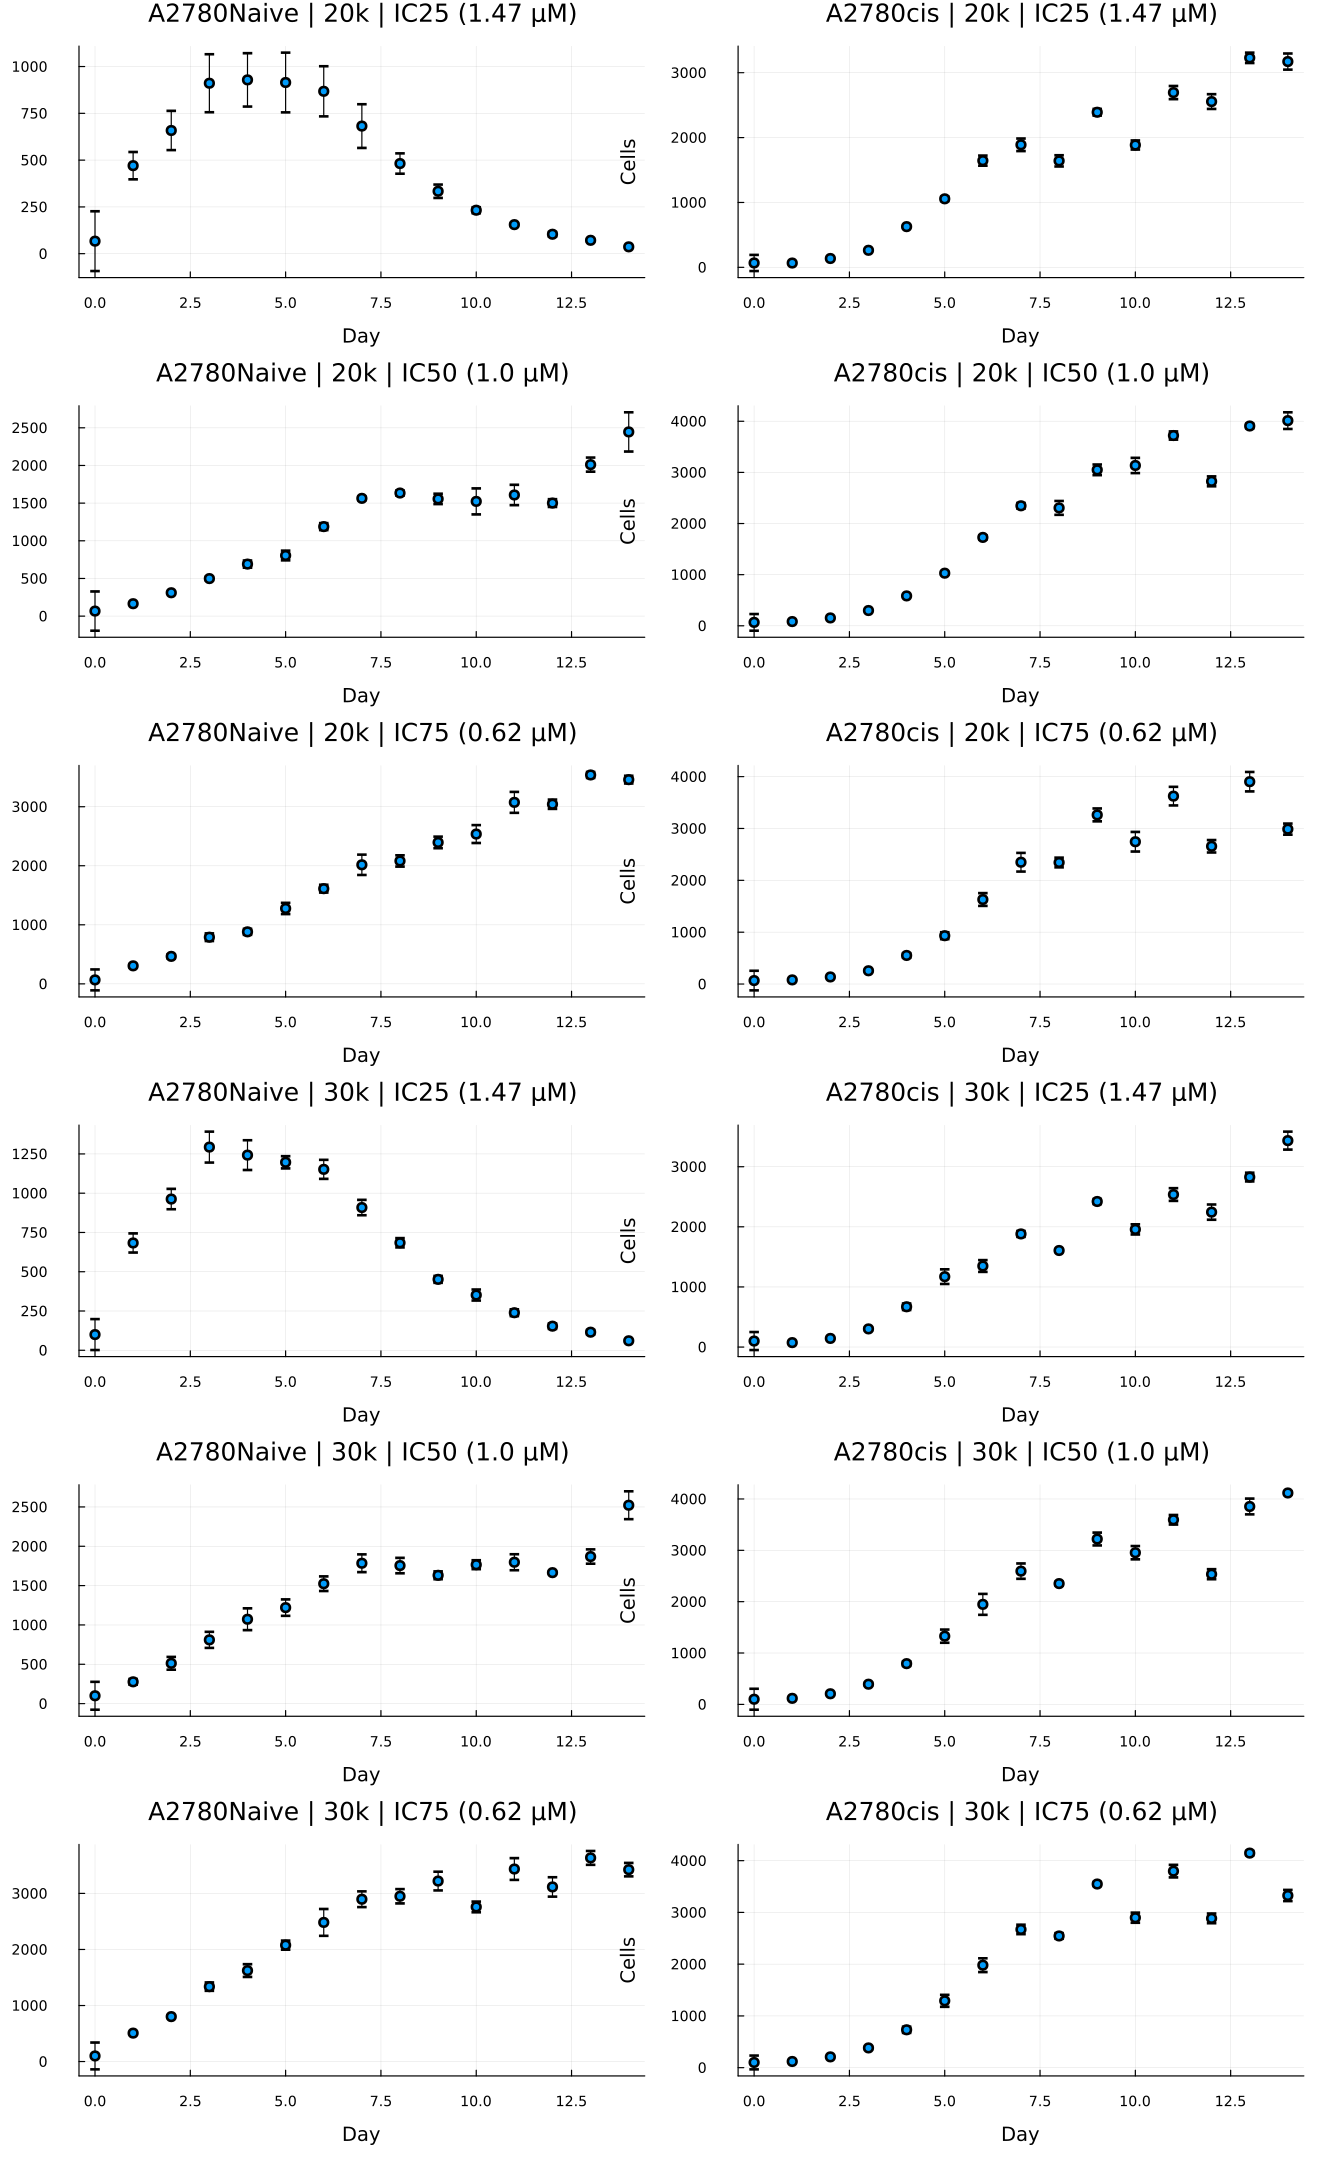

Plotted 12 treated monoculture datasets.


In [29]:
using Plots

############################################################
# Plot ALL treated monoculture datasets
# Expects output from:
#   treated_by_density_dose, treated_datasets =
#       load_treated_monoculture_datasets(...)
############################################################

if !(@isdefined treated_datasets) || isempty(treated_datasets)
    @warn "No treated datasets found. Run the treated monoculture loader first."
else
    plots_vec = Plots.Plot[]

    for ds in treated_datasets
        x    = ds[:x]
        y    = ds[:y]
        yerr = get(ds, :yerr, nothing)

        density = ds[:density]
        dose    = ds[:dose_label]
        cell    = ds[:cell_line]
        dose_uM = get(ds, :dose_uM, NaN)

        ttl = string(
            cell, " | ", density, " | ", dose,
            isnan(dose_uM) ? "" : " ($(dose_uM) µM)"
        )

        if yerr === nothing
            p = scatter(
                x, y;
                xlabel="Day",
                ylabel="Cells",
                title=ttl,
                markersize=4,
                label="Data"
            )
        else
            p = scatter(
                x, y;
                yerror=yerr,
                xlabel="Day",
                ylabel="Cells",
                title=ttl,
                markersize=4,
                label="Data"
            )
        end

        push!(plots_vec, p)
    end

    n = length(plots_vec)
    ncols = 2
    nrows = ceil(Int, n / ncols)

    plt = plot(
        plots_vec...;
        layout=(nrows, ncols),
        size=(1100, 300 * nrows),
        legend=false
    )

    display(plt)
    println("Plotted $(n) treated monoculture datasets.")
end


In [ ]:
using Plots
using DifferentialEquations
using Optim
using Statistics
using Printf

############################################################
# Joint fit (shared δ and n) across IC25/IC50/IC75
# per (density, cell_line)
#
# Model B (dose in µM):
#   dN/dt = r*N*(1 - N/K) - δ * H(D; IC50, n) * N
#   H(D)  = D^n / (IC50^n + D^n)
#
# IC50 is FIXED per cell line:
#   Naive: IC50 = 1 µM
#   Cis:   IC50 = 8 µM
#
# Fits:
#   δ, n shared across the 3 doses for that (density, cell_line)
# Fixed:
#   r, K from base_params[cell_line]
#   N0 from density (20k->67, 30k->100)
#
# Prints:
#   Group BIC + per-dose BICs + parameters
# Plots:
#   One overlay plot per group (IC25/50/75)
############################################################

# --------------------------
# 0) Baseline params required
# --------------------------
if !(@isdefined base_params)
    base_params = Dict{Symbol,NamedTuple{(:r,:K),Tuple{Float64,Float64}}}(
        :A2780Naive => (r=0.7, K=4000.0),
        :A2780cis   => (r=0.7, K=4000.0),
    )
end

# Fixed IC50 per cell line (µM)
const IC50_BY_CELL = Dict{Symbol,Float64}(
    :A2780Naive => 1.0,
    :A2780cis   => 8.0,
)

# --------------------------
# 1) Core functions
# --------------------------
function treated_logistic_death_ode!(du, u, p, t)
    # p = (r, K, δ, n, D, IC50)
    r, K, δ, n, D, IC50 = p
    N = u[1]
    H = (D^n) / (IC50^n + D^n)
    du[1] = r * N * (1 - N / K) - δ * H * N
end

function simulate_treated_at_times(x_in::AbstractVector{<:Real}, N0::Real,
                                  r::Real, K::Real, δ::Real, n::Real, D::Real;
                                  IC50::Real)
    x = Float64.(x_in)
    ord = sortperm(x)
    xs  = x[ord]
    t0, t1 = xs[1], xs[end]

    p = (Float64(r), Float64(K), Float64(δ), Float64(n), Float64(D), Float64(IC50))
    prob = ODEProblem(treated_logistic_death_ode!, [Float64(N0)], (t0, t1), p)
    sol = solve(prob, Tsit5();
        saveat=xs,
        abstol=1e-9, reltol=1e-9,
        maxiters=2_000_000
    )

    y_sorted = Array(sol)[1, :]
    yhat = similar(y_sorted)
    yhat[ord] = y_sorted
    return yhat
end

function rss(y::AbstractVector, yhat::AbstractVector; yerr=nothing)
    length(y) == length(yhat) || error("Length mismatch: y=$(length(y)) vs yhat=$(length(yhat))")
    if yerr === nothing
        r = y .- yhat
        return sum(r .^ 2)
    else
        w = 1.0 ./ (yerr .^ 2)
        r = y .- yhat
        return sum(w .* (r .^ 2))
    end
end

bic_from_rss(RSS::Real, nobs::Int, k::Int) = nobs * log(max(RSS, eps()) / nobs) + k * log(nobs)

function forced_N0_by_density(density_val)
    s = lowercase(string(density_val))
    if occursin("20", s)
        return 67.0
    elseif occursin("30", s)
        return 100.0
    else
        error("Cannot infer N0 from density=$(density_val).")
    end
end

function ensure_day0(x::Vector{Float64}, y::Vector{Float64}, yerr::Union{Nothing,Vector{Float64}}, N0::Float64)
    has0 = any(t -> isapprox(t, 0.0; atol=1e-12), x)
    if !has0
        x = vcat(0.0, x)
        y = vcat(N0, y)
        if yerr !== nothing
            yerr = vcat(maximum(yerr), yerr)
        end
    else
        idx0 = findfirst(t -> isapprox(t, 0.0; atol=1e-12), x)
        y[idx0] = N0
    end
    return x, y, yerr
end

# --------------------------
# 2) Group datasets
# --------------------------
function group_treated_datasets(treated_datasets)
    groups = Dict{Tuple{String,Symbol}, Vector{Dict{Symbol,Any}}}()  # key=(density, cell_line)
    for ds in treated_datasets
        dens = string(get(ds, :density, "unknown"))
        cell = Symbol(get(ds, :cell_line, :unknown))
        key = (dens, cell)
        if !haskey(groups, key)
            groups[key] = Dict{Symbol,Any}[]
        end
        push!(groups[key], ds)
    end
    return groups
end

# --------------------------
# 3) Joint fit for one group (shared δ,n)
# --------------------------
function fit_group_shared_delta_n(dsvec::Vector{Dict{Symbol,Any}};
    δ_lo::Float64=0.0, δ_hi::Float64=5.0,
    n_lo::Float64=0.2, n_hi::Float64=8.0,
    maxiters::Int=8000,
    dense_grid_points::Int=250
)
    dens = string(get(dsvec[1], :density, "unknown"))
    cell = Symbol(get(dsvec[1], :cell_line, :unknown))

    haskey(base_params, cell) || error("base_params missing entry for cell_line=$cell")
    r = base_params[cell].r
    K = base_params[cell].K
    N0 = forced_N0_by_density(dens)

    haskey(IC50_BY_CELL, cell) || error("IC50_BY_CELL missing entry for cell_line=$cell")
    IC50 = IC50_BY_CELL[cell]

    # Prepare datasets
    prepared = NamedTuple[]
    for ds in dsvec
        xraw  = Float64.(ds[:x])
        yraw  = Float64.(ds[:y])
        yerr0 = get(ds, :yerr, nothing)
        yerr0 = (yerr0 === nothing) ? nothing : Float64.(yerr0)

        ordt = sortperm(xraw)
        x = xraw[ordt]; y = yraw[ordt]
        yerr = (yerr0 === nothing) ? nothing : yerr0[ordt]

        x, y, yerr = ensure_day0(x, y, yerr, N0)

        mask = y .> 0
        x = x[mask]; y = y[mask]
        if yerr !== nothing
            yerr = yerr[mask]
        end

        D = Float64(get(ds, :dose_uM, NaN))
        isnan(D) && error("Dataset missing :dose_uM for file=$(get(ds,:file,\"?\"))")

        push!(prepared, (
            x=x, y=y, yerr=yerr, D=D,
            dose_label=string(get(ds, :dose_label, "unknown_dose")),
            file=string(get(ds, :file, "unknown_file"))
        ))
    end

    # Constraint transform: p = lo + (hi-lo)*σ(θ)
    σ(z) = 1.0 / (1.0 + exp(-z))
    invσ(p) = log(p / (1 - p))
    function unpack(θ)
        δ = δ_lo + (δ_hi - δ_lo) * σ(θ[1])
        n = n_lo + (n_hi - n_lo) * σ(θ[2])
        return δ, n
    end

    # init
    δ0 = clamp(0.5, δ_lo, δ_hi)
    n0 = clamp(2.0, n_lo, n_hi)
    θ0 = [
        invσ((δ0 - δ_lo) / (δ_hi - δ_lo + eps())),
        invσ((n0 - n_lo) / (n_hi - n_lo + eps()))
    ]

    # Joint objective: sum RSS across datasets
    function obj(θ)
        δ, n = unpack(θ)
        total = 0.0
        for pr in prepared
            yhat = simulate_treated_at_times(pr.x, N0, r, K, δ, n, pr.D; IC50=IC50)
            total += rss(pr.y, yhat; yerr=pr.yerr)
        end
        return total
    end

    opts = Optim.Options(iterations=maxiters, show_trace=false, show_warnings=false)
    res  = optimize(obj, θ0, BFGS(), opts)

    θ̂ = Optim.minimizer(res)
    δ̂, n̂ = unpack(θ̂)

    # Per-dataset metrics + group metrics
    per_ds = NamedTuple[]
    RSS_group = 0.0
    nobs_group = 0
    for pr in prepared
        yhat = simulate_treated_at_times(pr.x, N0, r, K, δ̂, n̂, pr.D; IC50=IC50)
        RSSi = rss(pr.y, yhat; yerr=pr.yerr)
        ni = length(pr.y)
        BICi = bic_from_rss(RSSi, ni, 2)  # k=2 (δ,n), reported per curve
        push!(per_ds, (dose_label=pr.dose_label, D=pr.D, file=pr.file, RSS=RSSi, BIC=BICi))
        RSS_group += RSSi
        nobs_group += ni
    end
    BIC_group = bic_from_rss(RSS_group, nobs_group, 2)

    # Overlay plot per group
    p = plot(
        title=string(cell, " | ", dens,
                     @sprintf("\nIC50 fixed=%.2g µM | shared fit: δ=%.4g, n=%.4g, BIC_group=%.3f",
                              IC50, δ̂, n̂, BIC_group)),
        xlabel="Day", ylabel="Cells"
    )

    for pr in prepared
        scatter!(p, pr.x, pr.y; markersize=4, label="Data $(pr.dose_label) (D=$(pr.D)µM)")
        tgrid = collect(range(min(0.0, minimum(pr.x)), maximum(pr.x); length=dense_grid_points))
        ygrid = simulate_treated_at_times(tgrid, N0, r, K, δ̂, n̂, pr.D; IC50=IC50)
        plot!(p, tgrid, ygrid; linewidth=2, label="Fit $(pr.dose_label)")
    end

    return (density=dens, cell_line=cell, IC50=IC50, r=r, K=K, N0=N0,
            δ=δ̂, n=n̂,
            RSS_group=RSS_group, nobs_group=nobs_group, BIC_group=BIC_group,
            per_dataset=per_ds,
            plot=p, optim_result=res)
end

# --------------------------
# 4) Run joint fits across all (density, cell_line) groups
# --------------------------
if !(@isdefined treated_datasets) || isempty(treated_datasets)
    @warn "No treated datasets found. Run your treated loader first."
else
    groups = group_treated_datasets(treated_datasets)

    group_results = NamedTuple[]
    group_plots = Plots.Plot[]

    # stable ordering
    keys_sorted = sort(collect(keys(groups)); by=k->(k[1], string(k[2])))

    for key in keys_sorted
        dsvec = groups[key]
        dens, cell = key

        # keep only IC25/IC50/IC75 entries if dose_label exists
        ds_use = [ds for ds in dsvec if occursin("IC", uppercase(string(get(ds, :dose_label, ""))))]
        isempty(ds_use) && continue

        gr = fit_group_shared_delta_n(ds_use; δ_hi=5.0, n_hi=8.0, maxiters=8000)
        push!(group_results, gr)
        push!(group_plots, gr.plot)
    end

    println("\n===== Joint Fits (shared δ,n) per (density, cell_line) | IC50 fixed per cell =====")
    @printf("%-4s %-10s %-10s %-8s %-12s %-12s %-12s %-12s\n",
            "Idx","Density","Cell","IC50","BIC_group","δ","n","RSS_group")
    for (i, g) in enumerate(group_results)
        @printf("%-4d %-10s %-10s %-8.3g %-12.3f %-12.4g %-12.4g %-12.4g\n",
                i, string(g.density), string(g.cell_line), g.IC50, g.BIC_group, g.δ, g.n, g.RSS_group)

        for pd in g.per_dataset
            @printf("      %-7s D=%-8.4g  BIC=%-10.3f  RSS=%-10.4g  file=%s\n",
                    string(pd.dose_label), pd.D, pd.BIC, pd.RSS, pd.file)
        end
    end

    if !isempty(group_plots)
        n = length(group_plots)
        ncols = 2
        nrows = ceil(Int, n / ncols)
        plt = plot(group_plots...; layout=(nrows, ncols), size=(1100, 380*nrows), legend=true)
        display(plt)
        println("\nPlotted $(n) joint-fit group overlays.")
    end
end
